In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# 1. Load Data Lokal
# Ganti 'nama_file.json' dengan file yang kamu punya di folder
file_path = r'C:\Users\muham\授業\TBAFootballDataAnalyst\rjp_soccer\open-data\data\matches\43\106.json' # Sesuaikan path ini
with open(file_path, encoding='utf-8') as f:
    data = json.load(f)

# 2. Convert ke DataFrame (Flattening)
# Data StatsBomb itu JSON, kita harus ubah jadi Tabel agar bisa dianalisis
df = pd.json_normalize(data, sep="_")

# Cek data
print(f"Total Event: {len(df)}")
df.head()

Total Event: 64


,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,competition_stage_id,competition_stage_name,stadium_id,stadium_name,stadium_country_id,stadium_country_name,referee_id,referee_name,referee_country_id,referee_country_name
0,3857256,2022-12-02,21:00:00.000,2,3,available,available,2023-02-17T23:45:15.306706,2023-04-26T23:49:58.956186,3,...,10,Group Stage,1001115,Stadium 974,185,Qatar,1121.0,Fernando Andrés Rapallini,11.0,Argentina
1,3869151,2022-12-03,21:00:00.000,2,1,available,available,2023-07-30T07:46:05.382784,2023-07-30T07:48:51.865595,4,...,33,Round of 16,1000793,Ahmad bin Ali Stadium,185,Qatar,367.0,Szymon Marciniak,182.0,Poland
2,3857257,2022-11-30,17:00:00.000,1,0,available,available,2023-04-28T17:13:10.958725,2023-06-20T11:04:37.638969,3,...,10,Group Stage,117897,Al Janoub Stadium,185,Qatar,2311.0,Mustapha Ghorbal,4.0,Algeria
3,3857258,2022-11-24,21:00:00.000,2,0,available,available,2023-06-24T17:17:27.911026,2023-07-11T14:56:31.096588,1,...,10,Group Stage,1001114,Lusail Stadium,185,Qatar,741.0,Alireza Faghani,107.0,"Iran, Islamic Republic of"
4,3857288,2022-11-26,12:00:00.000,0,1,available,available,2023-02-28T21:25:20.888552,2023-04-27T00:30:07.835815,2,...,10,Group Stage,117897,Al Janoub Stadium,185,Qatar,225.0,Daniel Siebert,85.0,Germany


In [3]:
# Cari pertandingan dimana Home = Japan ATAU Away = Japan
# Tanda '|' artinya 'OR' (atau)
match_jepang = df[ (df['home_team_home_team_name'] == 'Japan') | 
                   (df['away_team_away_team_name'] == 'Japan') ]

# Tampilkan hanya kolom penting agar mudah dibaca
info_penting = match_jepang[['match_id', 'match_date', 'home_team_home_team_name', 'away_team_away_team_name', 'home_score', 'away_score']]

print("Daftar Pertandingan Jepang yang ditemukan:")
print(info_penting)

Daftar Pertandingan Jepang yang ditemukan:
    match_id  match_date home_team_home_team_name away_team_away_team_name  \
24   3869219  2022-12-05                    Japan                  Croatia   
31   3857295  2022-11-27                    Japan               Costa Rica   
33   3857284  2022-11-23                  Germany                    Japan   
62   3857255  2022-12-01                    Japan                    Spain   

    home_score  away_score  
24           1           1  
31           0           1  
33           1           2  
62           2           1  


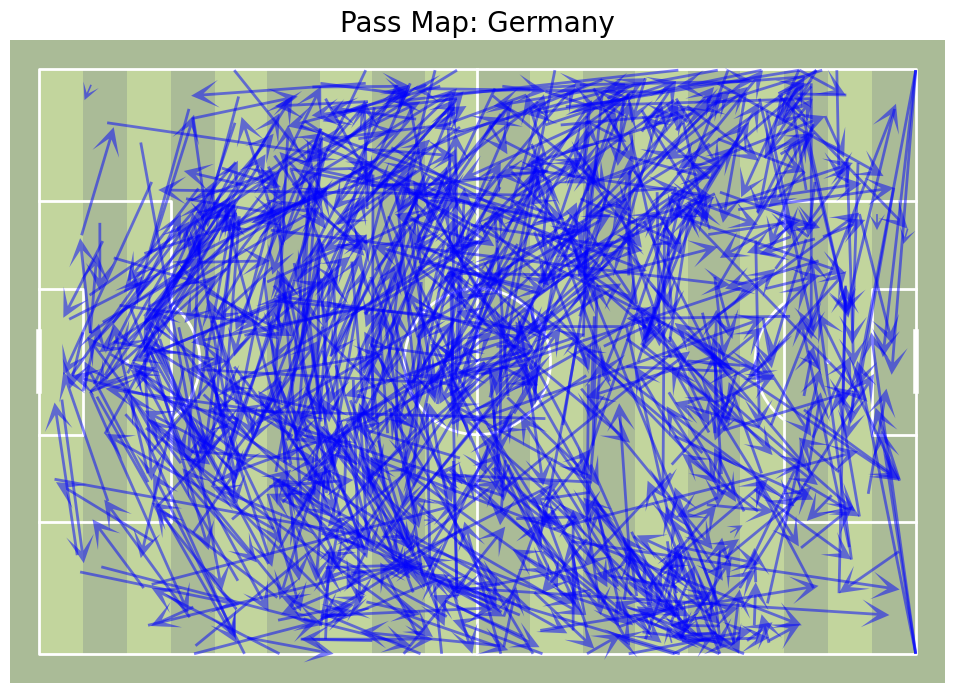

In [4]:
# --- LANGKAH 1: BUKA KOTAK DATA (Loading) ---
# Pastikan path ini mengarah ke file EVENT (bukan match), misal: 12345.json
event_path = 'C:\\Users\\muham\\授業\\TBAFootballDataAnalyst\\rjp_soccer\\open-data\\data\\events\\3857284.json'  
# ^ Ganti angka ID di atas dengan file yang kamu punya di folder events

with open(event_path, encoding='utf-8') as f:
    data_mentah = json.load(f)

# --- LANGKAH 2: MERATAKAN DATA (Flattening) ---
# Data JSON itu bertingkat-tingkat. Kita ratakan jadi tabel excel (DataFrame)
df_events = pd.json_normalize(data_mentah, sep="_")

# --- LANGKAH 3: MENYARING DATA (Filtering) ---
# Kita hanya butuh data operan (Pass) dari satu tim
nama_tim = 'Germany'  # Ganti dengan nama tim yang ada di datamu
df_pass = df_events[(df_events['type_name'] == 'Pass') & (df_events['team_name'] == nama_tim)].copy()

# --- LANGKAH 4: MEMECAH & MEMPERBAIKI TIPE DATA (Transformation) ---
# Disini kunci perbaikan error-nya!

# A. Ambil koordinat X dan Y dari kolom 'location' yang bentuknya list [x, y]
# Kita pakai .apply() untuk mengambil angka di dalam list
df_pass['x'] = df_pass['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else None)
df_pass['y'] = df_pass['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else None)

# B. Ambil koordinat tujuan (End X, End Y)
df_pass['end_x'] = df_pass['pass_end_location'].apply(lambda loc: loc[0] if isinstance(loc, list) else None)
df_pass['end_y'] = df_pass['pass_end_location'].apply(lambda loc: loc[1] if isinstance(loc, list) else None)

# C. Hapus data kosong (jika ada pass yang tidak punya lokasi)
df_pass = df_pass.dropna(subset=['x', 'y', 'end_x', 'end_y'])

# D. KONVERSI TIPE DATA (PENTING!)
# Memaksa teks berubah jadi angka desimal (Float)
df_pass['x'] = df_pass['x'].astype(float)
df_pass['y'] = df_pass['y'].astype(float)
df_pass['end_x'] = df_pass['end_x'].astype(float)
df_pass['end_y'] = df_pass['end_y'].astype(float)

# --- LANGKAH 5: MENGGAMBAR (Visualization) ---
pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97', line_color='white', stripe=True)
fig, ax = pitch.draw(figsize=(10, 7))

pitch.arrows(df_pass.x, df_pass.y,
             df_pass.end_x, df_pass.end_y, 
             width=2, headwidth=10, headlength=10, 
             color='blue', ax=ax, label='Passes', alpha=0.5)

plt.title(f'Pass Map: {nama_tim}', fontsize=20)
plt.show()

In [5]:
# Cek daftar nama pemain yang ada di data (supaya tidak salah ketik)
print(df_pass['player_name'].unique())

['Kai Havertz' 'Joshua Kimmich' 'Manuel Neuer' 'Nico Schlotterbeck'
 'Antonio Rüdiger' 'Niklas Süle' 'David Raum' 'Jamal Musiala'
 'Serge Gnabry' 'Thomas Müller' 'İlkay Gündoğan' 'Jonas Hofmann'
 'Leon Goretzka' 'Mario Götze' 'Niclas Füllkrug' 'Youssoufa Moukoko']


Statistik Joshua Kimmich:
Total Pass: 97
Sukses: 82
Akurasi: 84.5%


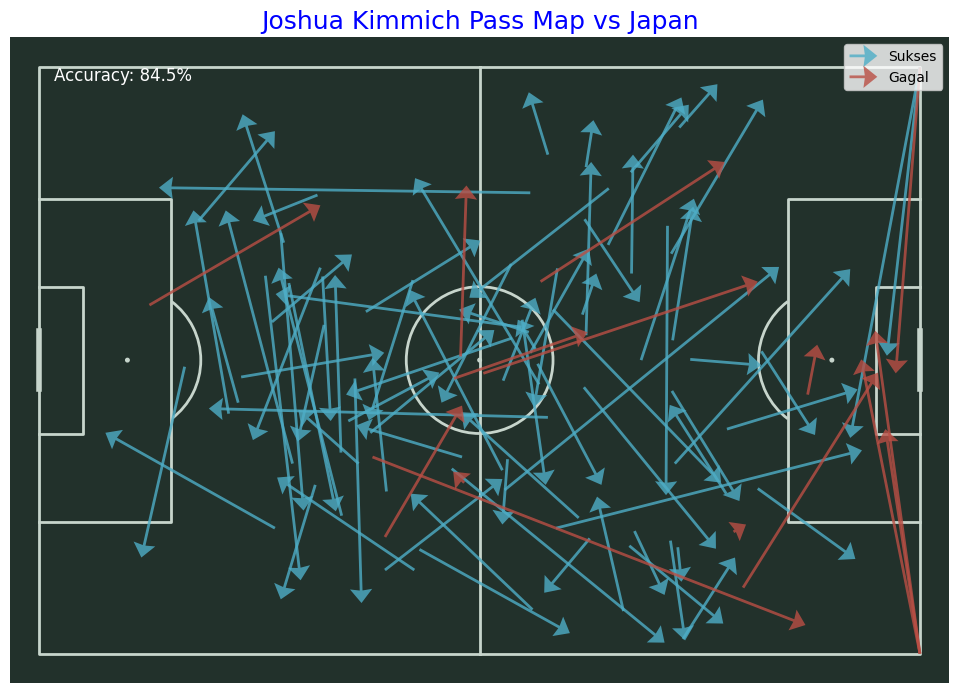

In [6]:
# --- PILIH PEMAIN ---
target_player = 'Joshua Kimmich' # Ganti dengan nama yang muncul di list tadi
# Filter data hanya untuk pemain ini
player_pass = df_pass[df_pass['player_name'] == target_player].copy()

# --- HITUNG STATISTIK SEDERHANA (Penting untuk HR!) ---
# Di StatsBomb, jika kolom 'pass_outcome_name' isinya NaN (kosong), artinya SUKSES.
# Jika ada isinya (Incomplete, Out, dll), artinya GAGAL.
pass_total = len(player_pass)
pass_sukses = len(player_pass[player_pass['pass_outcome_name'].isna()])
akurasi = (pass_sukses / pass_total) * 100

print(f"Statistik {target_player}:")
print(f"Total Pass: {pass_total}")
print(f"Sukses: {pass_sukses}")
print(f"Akurasi: {akurasi:.1f}%")

# --- VISUALISASI PRO (Sukses=Biru, Gagal=Merah) ---
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(10, 7))

# 1. Gambar Pass Sukses (Biru)
sukses = player_pass[player_pass['pass_outcome_name'].isna()]
pitch.arrows(sukses.x, sukses.y, sukses.end_x, sukses.end_y,
             width=2, headwidth=8, color='#4eaec7', ax=ax, label='Sukses', alpha=0.8)

# 2. Gambar Pass Gagal (Merah)
gagal = player_pass[player_pass['pass_outcome_name'].notna()]
pitch.arrows(gagal.x, gagal.y, gagal.end_x, gagal.end_y,
             width=2, headwidth=8, color='#ba4f45', ax=ax, label='Gagal', alpha=0.8)

# 3. Judul & Info
ax.set_title(f'{target_player} Pass Map vs Japan', fontsize=18, color='blue')
# Menambah teks akurasi di pojok grafik
ax.text(2, 2, f'Accuracy: {akurasi:.1f}%', color='white', fontsize=12)

plt.legend()
plt.show()

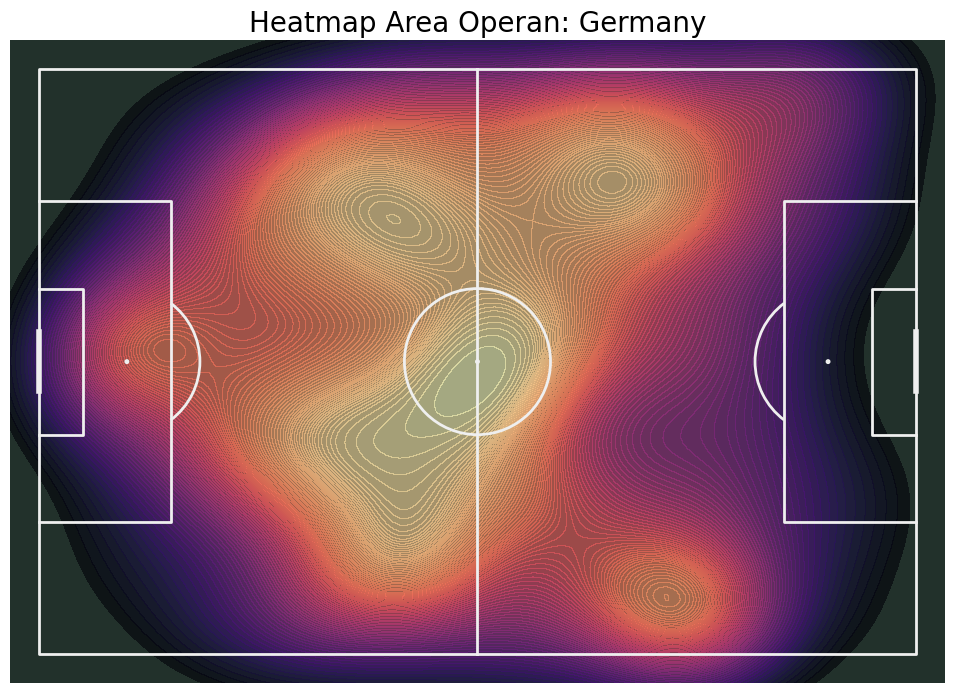

In [7]:
import seaborn as sns # Library untuk visualisasi statistik (Warna-warni)

# 1. Setup Lapangan
# Kita pakai warna gelap biar Heatmap-nya menyala ('magma' colormap)
pitch = Pitch(pitch_type='statsbomb', line_zorder=2,
              pitch_color='#22312b', line_color='#efefef')

fig, ax = pitch.draw(figsize=(10, 7))

# 2. Buat Heatmap (KDE Plot)
# kdeplot akan menghitung kepadatan (density) operan di setiap titik
kde = sns.kdeplot(
    x=df_pass.x, 
    y=df_pass.y, 
    fill=True,       # Isi dengan warna
    thresh=0.05,     # Hapus area yang aktivitasnya sangat sedikit (biar bersih)
    levels=100,      # Jumlah tingkatan warna (makin tinggi makin halus)
    cmap='magma',    # Pilihan warna: magma, coolwarm, viridis
    alpha=0.6,       # Transparansi (supaya garis lapangan tetap kelihatan)
    ax=ax            # Gambar di atas lapangan yang sudah kita buat
)

# 3. Judul
plt.title(f'Heatmap Area Operan: {nama_tim}', fontsize=20, color='black')
plt.show()

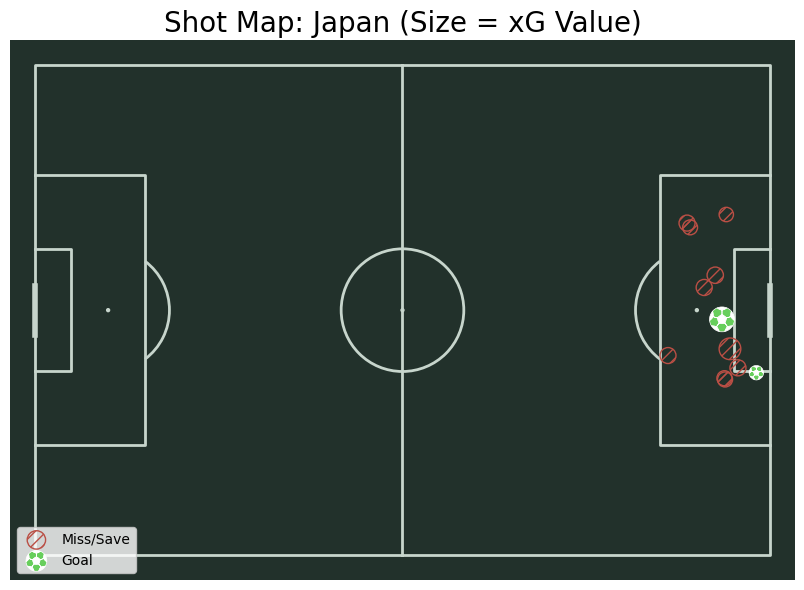

Total Expected Goals (xG): 1.25
Actual Goals: 2


In [8]:
# --- LANGKAH 1: FILTER DATA SHOT ---
# Ambil data shot dari satu tim saja (misal: Germany atau tim pilihanmu)
team_name = 'Japan' # Sesuaikan dengan tim yang kamu analisis
shots = df_events[
    (df_events['type_name'] == 'Shot') & 
    (df_events['team_name'] == team_name)
].copy()

# --- LANGKAH 2: PERBAIKI KOORDINAT (Wajib) ---
shots['x'] = shots['location'].apply(lambda x: x[0])
shots['y'] = shots['location'].apply(lambda x: x[1])

# --- LANGKAH 3: MEMISAHKAN GOL & TIDAK GOL ---
# Kita butuh dua kelompok data agar warnanya bisa beda
goals = shots[shots['shot_outcome_name'] == 'Goal']
non_goals = shots[shots['shot_outcome_name'] != 'Goal']

# --- LANGKAH 4: VISUALISASI ---
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(10, 6))

# A. Gambar yang TIDAK GOL (Warna Merah Pudar)
# Parameter 's' adalah Size (Ukuran). Kita kalikan xG dengan 500 biar lingkarannya kelihatan.
pitch.scatter(non_goals.x, non_goals.y,
              s=(non_goals['shot_statsbomb_xg'] * 500) + 100, 
              edgecolors='#ba4f45', c='None', # Bagian tengah bolong (transparan)
              hatch='///', # Arsiran garis
              marker='o', ax=ax, label='Miss/Save')

# B. Gambar yang GOL (Warna Hijau/Emas Solid)
pitch.scatter(goals.x, goals.y,
              s=(goals['shot_statsbomb_xg'] * 500) + 100,
              edgecolors='white', c='#67ce5c', # Warna solid
              marker='football', # Ikon bola (fitur keren mplsoccer!)
              ax=ax, label='Goal')

# C. Tambahkan Judul & Legenda
plt.title(f'Shot Map: {team_name} (Size = xG Value)', fontsize=20)
plt.legend(loc='lower left')
plt.show()

# Print Total xG untuk Analisis
total_xg = shots['shot_statsbomb_xg'].sum()
actual_goals = len(goals)
print(f"Total Expected Goals (xG): {total_xg:.2f}")
print(f"Actual Goals: {actual_goals}")

Analisis dilakukan dari menit 0 sampai menit ke-66


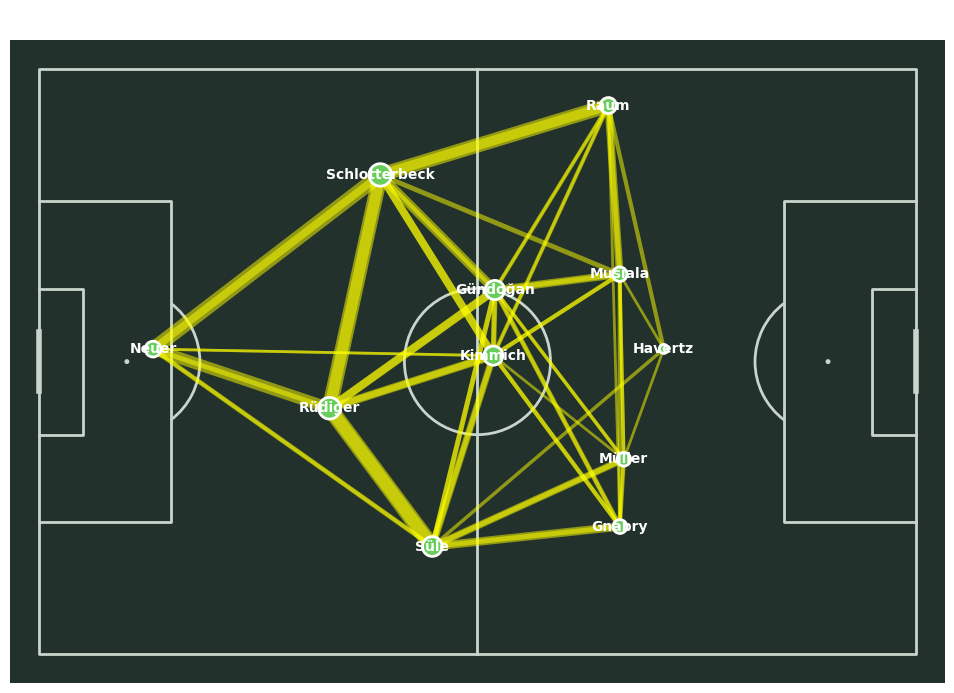

In [9]:
# --- LANGKAH 1: PERSIAPAN DATA ---
# Ganti dengan nama tim yang ingin kamu analisis
team_name = 'Germany'

# Cari menit pertama kali ada pergantian pemain (Substitution)
# Kita hanya ambil data SEBELUM sub pertama agar formasi murni
subs = df_events[
    (df_events['type_name'] == 'Substitution') &
    (df_events['team_name'] == team_name)
]
# Jika tidak ada sub (jarang terjadi), anggap main full 120 menit
first_sub_min = subs['minute'].min() if not subs.empty else 120

print(f"Analisis dilakukan dari menit 0 sampai menit ke-{first_sub_min}")

# Filter Data:
# 1. Hanya Tim Tersebut
# 2. Hanya Tipe 'Pass'
# 3. Hanya yang SUKSES (pass_outcome_name is NaN)
# 4. Hanya sebelum pergantian pemain pertama
pass_raw = df_events[
    (df_events['team_name'] == team_name) &
    (df_events['type_name'] == 'Pass') &
    (df_events['pass_outcome_name'].isna()) &
    (df_events['minute'] < first_sub_min)
].copy()

# Fix Koordinat (Jaga-jaga kalau belum difloat)
pass_raw['x'] = pass_raw['location'].apply(lambda x: x[0])
pass_raw['y'] = pass_raw['location'].apply(lambda x: x[1])


# --- LANGKAH 2: HITUNG LOKASI RATA-RATA PEMAIN (NODES) ---
# Group by nama pemain, lalu cari rata-rata x dan y nya
average_loc = pass_raw.groupby('player_name').agg({'x': ['mean'], 'y': ['mean', 'count']})
average_loc.columns = ['x', 'y', 'count'] # Rename kolom biar gampang

# --- LANGKAH 3: HITUNG JUMLAH OPERAN ANTAR PEMAIN (EDGES) ---
# Kita hitung: Si A oper ke Si B berapa kali?
pass_between = pass_raw.groupby(['player_name', 'pass_recipient_name']).size().reset_index(name='pass_count')

# Gabungkan data lokasi pengoper (x, y) dan penerima (x_end, y_end)
pass_between = pass_between.merge(average_loc, left_on='player_name', right_index=True)
pass_between = pass_between.merge(average_loc, left_on='pass_recipient_name', right_index=True, suffixes=('', '_end'))

# Filter: Hanya tampilkan koneksi yang terjadi lebih dari 3 kali (biar grafik tidak kotor)
pass_between = pass_between[pass_between['pass_count'] > 3]


# --- LANGKAH 4: VISUALISASI ---
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(10, 7))

# A. Gambar Garis Operan (Edges)
# Ketebalan garis (alpha/width) ditentukan oleh jumlah operan (pass_count)
pitch.lines(pass_between.x, pass_between.y,
            pass_between.x_end, pass_between.y_end,
            lw=pass_between.pass_count * 0.5, # Garis makin tebal kalau sering oper
            color='#ffff00', zorder=1, alpha=0.5, ax=ax)

# B. Gambar Posisi Pemain (Nodes)
# Ukuran titik ditentukan oleh seberapa sering dia terlibat (count)
pitch.scatter(average_loc.x, average_loc.y,
              s=average_loc['count'] * 3, # Titik makin besar kalau sering pegang bola
              color='#67ce5c', edgecolors='white', linewidth=2, alpha=1, zorder=2, ax=ax)

# C. Tulis Nama Pemain
for index, row in average_loc.iterrows():
    # Ambil nama belakang saja biar tidak kepanjangan
    simple_name = index.split(' ')[-1]
    pitch.annotate(simple_name, xy=(row.x, row.y), c='white', va='center', ha='center', size=10, ax=ax, fontweight='bold')

plt.title(f'Pass Network: {team_name} (Until 1st Sub)', fontsize=20, color='white')
plt.show()